# UC-001 — Exploring late spring frost risk for Swiss apiaries

Use case: [`docs/specs/UC-001-EXPLORE-FROST-RISK.md`](../docs/specs/UC-001-EXPLORE-FROST-RISK.md).
Goal: choose a defensible **frost-day definition** and **canton risk metric**
from data and cited sources, as input for ADR-002 (CRISP-DM: data understanding).

**Run:** `jupyter nbconvert --to notebook --execute --inplace notebooks/uc-001-explore-frost-risk.ipynb`
(downloads into the git-ignored `data/raw/`, reused on later runs).

### Harm mechanism targeted
Late frost can harm colonies in two ways that need **different definitions**:
1. **Forage loss** — frost kills open blossom of spring forage plants (fruit trees, dandelion),
   so colonies lose nectar and pollen during build-up. Relevant: air minimum at canopy height
   relative to a bud-stage damage threshold, *after* flowering has started.
2. **Brood chilling** — a cold spell after brood expansion makes the cluster contract and leave
   brood uncovered. Relevant: multi-day cold periods (daily mean), largely independent of a
   frost threshold.

**This notebook targets forage loss (1).** Brood chilling is not modelled here; it would need a
cold-spell definition and is listed as an option for ADR-002.

### Data and attribution
- Temperatures and station metadata: Source: MeteoSwiss, SwissMetNet open data
  (`ch.meteoschweiz.ogd-smn`), CC BY 4.0. Raw measurements, **not homogenised**.
- Flowering dates: Source: MeteoSwiss, phenological observations open data
  (`ch.meteoschweiz.ogd-phenology`), CC BY 4.0.
- Colonies per canton (2022): Charrière, J.-D. & Würgler, O. (2024).
  *Bienenhaltung in der Schweiz und im internationalen Vergleich.* Agroscope
  Transfer 528, Table 2 (data: AGIS, FOAG). © Agroscope; downloaded and parsed
  at run time, not redistributed.

### Evidence used
- Blossom bud damage depends on bud stage (Ballard, Proebsting & Tukey; WSU Extension EB0913 apples,
  EB1128 cherries; 10 % kill, 30 min): apple silver tip −9.4 °C, green tip −7.8 °C, tight cluster
  −2.8 °C, first pink to post-bloom −2.2 °C; cherry first swelling −8.3 °C, green tip −3.9 °C,
  tight cluster −3.3 °C, first bloom to post-bloom −2.2 °C. **−2.2 °C applies only from
  (about) first bloom**; earlier stages are much hardier.
- Spring frost damage risk depends on timing relative to vegetation development, not only on
  frost frequency — Vitasse, Y. & Rebetez, M. (2018). *Unprecedented risk of spring frost damage
  in Switzerland and Germany in 2017.* Climatic Change 149, 233–246.
- Cold stress on brood: Ramirez, L., Luna, F., Mucci, C. A. & Lamattina, L. (2021). *Fast weight
  recovery, metabolic rate adjustment and gene-expression regulation define responses of
  cold-stressed honey bee brood.* Journal of Insect Physiology 128 (peer-reviewed version of
  bioRxiv 2020.06.15.152389).
- Growing season start: first span of ≥ 6 days with daily mean > 5 °C (ETCCDI index GSL).

In [1]:
from pathlib import Path
import re
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, kendalltau, theilslopes

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

SMN = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn"
PHEN = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-phenology"
AGROSCOPE_PDF = "https://ira.agroscope.ch/de-CH/Page/Einzelpublikation/Download?einzelpublikationId=60413"

SAMPLE = ["BAS", "BER", "ABO", "GVE", "CGI", "SIO", "LUG", "MAG", "CHU", "DAV", "SMA", "WAE", "STG"]
SPRING = [3, 4, 5, 6]
COMPARISON_START = 1981
MIN_COVERAGE = 0.9
BLOSSOM_C = -2.2

def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    centre = (p + z * z / (2 * n)) / (1 + z * z / n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return (centre - half, centre + half)

def fetch(url, name):
    path = RAW / name
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return path

## 1. Station network
How many SwissMetNet stations does each canton have? Summing frost days over stations (the prototype) inflates cantons with many stations.

159 stations in 25 cantons/areas; cantons without a station: ['AR', 'NW']


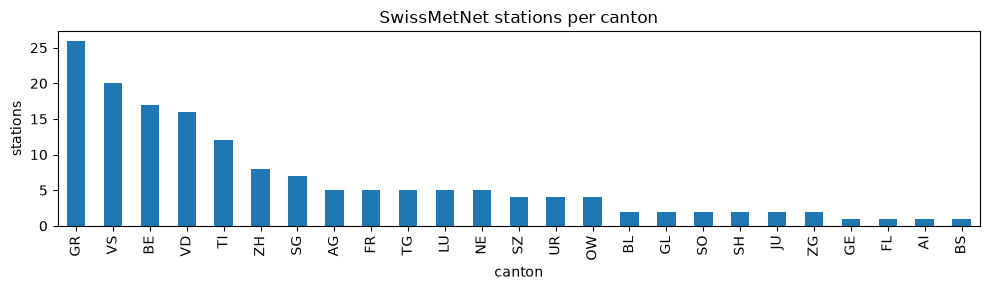

,name,canton,elevation_m,exposition
station,,,,
MAG,Magadino / Cadenazzo,TI,203.0,plain
LUG,Lugano,TI,273.0,plain
BAS,Basel / Binningen,BL,316.0,height (30-100 m above valley)
GVE,Genève / Cointrin,GE,411.0,plain
CGI,Nyon / Changins,VD,458.0,height (30-100 m above valley)
SIO,Sion,VS,482.0,plain
WAE,Wädenswil,ZH,485.0,north-eastern oriented slope
BER,Bern / Zollikofen,BE,553.0,plain
CHU,Chur,GR,556.0,plain


In [2]:
stations = pd.read_csv(fetch(f"{SMN}/ogd-smn_meta_stations.csv", "ogd-smn_meta_stations.csv"),
                       sep=";", encoding="latin1")
stations = stations.rename(columns={"station_abbr": "station", "station_canton": "canton",
                                    "station_height_masl": "elevation_m", "station_name": "name",
                                    "station_exposition_en": "exposition",
                                    "station_coordinates_lv95_east": "east", "station_coordinates_lv95_north": "north"})
CANTONS = "AG AI AR BE BL BS FR GE GL GR JU LU NE NW OW SG SH SO SZ TG TI UR VD VS ZG ZH".split()
per_canton = stations.groupby("canton").size().sort_values(ascending=False)
print(f"{len(stations)} stations in {per_canton.size} cantons/areas; "
      f"cantons without a station: {sorted(set(CANTONS) - set(per_canton.index))}")
ax = per_canton.plot.bar(figsize=(10, 3), color="tab:blue", title="SwissMetNet stations per canton")
ax.set_ylabel("stations"); plt.tight_layout(); plt.show()

sample_meta = stations.set_index("station").loc[SAMPLE, ["name", "canton", "elevation_m", "exposition", "east", "north"]]
order = sample_meta.sort_values("elevation_m").index
sample_meta.loc[order, ["name", "canton", "elevation_m", "exposition"]]

## 2. Daily data for the sample
Historical and recent files are combined; recent values win on overlap. Parameters: `tre200dn` (2 m air minimum), `tre005dn` (5 cm above grass minimum), `tre200d0` (2 m daily mean).

In [3]:
PARAMS = ["tre200dn", "tre005dn", "tre200d0"]

def load_station(abbr):
    parts = []
    for period in ("historical", "recent"):
        name = f"ogd-smn_{abbr.lower()}_d_{period}.csv"
        df = pd.read_csv(fetch(f"{SMN}/{abbr.lower()}/{name}", name), sep=";", encoding="latin1",
                         usecols=lambda c: c in ["station_abbr", "reference_timestamp"] + PARAMS)
        parts.append(df)
    df = pd.concat(parts, ignore_index=True)
    df["date"] = pd.to_datetime(df["reference_timestamp"], format="%d.%m.%Y %H:%M")
    df = df.drop_duplicates("date", keep="last").drop(columns="reference_timestamp")
    for p in PARAMS:
        if p not in df:
            df[p] = np.nan
    return df.rename(columns={"station_abbr": "station"})

daily = pd.concat([load_station(s) for s in SAMPLE], ignore_index=True)
daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month
daily["doy"] = daily["date"].dt.dayofyear

bad = daily[(daily["tre200dn"] < -50) | (daily["tre200dn"] > 40) | (daily["tre005dn"] < -50) | (daily["tre005dn"] > 40)]
print(f"{len(daily):,} station-days; implausible values excluded: {len(bad)}")
daily = daily.drop(bad.index)

last_complete = int(daily.loc[daily["date"].dt.strftime("%m-%d") == "06-30", "year"].max())
print("first year with data per parameter (sample):")
daily.groupby("station")[PARAMS].apply(lambda g: g.apply(lambda s: s.first_valid_index())).map(
    lambda i: daily.at[i, "date"].year if pd.notna(i) else None).loc[SAMPLE]

579,436 station-days; implausible values excluded: 1


first year with data per parameter (sample):


,tre200dn,tre005dn,tre200d0
station,,,
BAS,1865,1981,1864
BER,1864,1981,1864
ABO,1966,1983,1959
GVE,1954,1958,1954
CGI,1965,1981,1965
SIO,1958,1958,1958
LUG,1864,1981,1864
MAG,1953,1958,1953
CHU,1958,1981,1887


## 3. Data quality
A **station-year** is valid for a parameter when at least 90 % of its March–June days are present (for the thermal sum: 90 % of January–June). Comparison period: 1981 to the last complete spring.

In [4]:
def coverage(frame, months, first_month, params):
    sub = frame[frame["month"].isin(months)]
    counts = sub.groupby(["station", "year"])[params].count()
    years = counts.index.get_level_values("year")
    expected = np.array([(pd.Timestamp(y, 6, 30) - pd.Timestamp(y, first_month, 1)).days + 1 for y in years])
    return counts.div(expected, axis=0) >= MIN_COVERAGE

spring = daily[daily["month"].isin(SPRING)]
valid = coverage(daily, SPRING, 3, PARAMS)
valid_h1 = coverage(daily, range(1, 7), 1, ["tre200d0"])["tre200d0"].rename("ok_h1")

period = (valid.index.get_level_values("year") >= COMPARISON_START) & (valid.index.get_level_values("year") <= last_complete)
n_years = last_complete - COMPARISON_START + 1
quality = valid[period].groupby("station").sum().loc[SAMPLE]
quality.columns = [f"valid years {c}" for c in quality.columns]
print(f"Comparison period {COMPARISON_START}–{last_complete} ({n_years} springs)")
quality.join(sample_meta[["canton", "elevation_m"]])

Comparison period 1981–2026 (46 springs)


,valid years tre200dn,valid years tre005dn,valid years tre200d0,canton,elevation_m
station,,,,,
BAS,46,46,46,BL,316.0
BER,46,46,46,BE,553.0
ABO,46,43,46,BE,1321.0
GVE,46,46,46,GE,411.0
CGI,46,46,46,VD,458.0
SIO,46,46,46,VS,482.0
LUG,46,46,46,TI,273.0
MAG,46,46,46,TI,203.0
CHU,46,43,46,GR,556.0


## 4. When does spring frost occur?
Mean number of frost days (air minimum ≤ 0 °C) per month and valid station-year, comparison period, stations ordered by elevation.

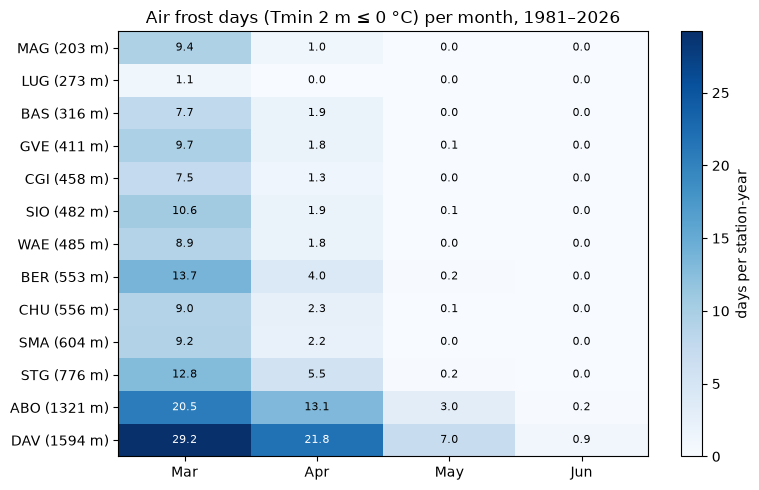

month,Mar,Apr,May,Jun
MAG (203 m),9.39,1.04,0.00,0.00
LUG (273 m),1.07,0.02,0.00,0.00
BAS (316 m),7.74,1.87,0.04,0.00
GVE (411 m),9.67,1.83,0.07,0.00
CGI (458 m),7.50,1.33,0.02,0.00
SIO (482 m),10.57,1.91,0.09,0.00
WAE (485 m),8.91,1.83,0.00,0.00
BER (553 m),13.70,4.04,0.20,0.00
CHU (556 m),9.00,2.30,0.07,0.00
SMA (604 m),9.17,2.17,0.02,0.00


In [5]:
cmp = spring[(spring["year"] >= COMPARISON_START) & (spring["year"] <= last_complete)].copy()
cmp = cmp.join(valid.rename(columns=lambda c: f"ok_{c}"), on=["station", "year"])

air = cmp[cmp["ok_tre200dn"]]
monthly = (air.assign(frost=air["tre200dn"] <= 0)
              .groupby(["station", "year", "month"])["frost"].sum()
              .groupby(["station", "month"]).mean().unstack("month"))
monthly = monthly.loc[order].rename(columns={3: "Mar", 4: "Apr", 5: "May", 6: "Jun"})
monthly.index = [f"{s} ({int(sample_meta.at[s, 'elevation_m'])} m)" for s in monthly.index]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(monthly.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(4), monthly.columns); ax.set_yticks(range(len(monthly)), monthly.index)
for (i, j), v in np.ndenumerate(monthly.values):
    ax.text(j, i, f"{v:.1f}", ha="center", va="center", color="white" if v > monthly.values.max() / 2 else "black", fontsize=8)
ax.set_title(f"Air frost days (Tmin 2 m ≤ 0 °C) per month, {COMPARISON_START}–{last_complete}")
fig.colorbar(im, label="days per station-year"); plt.tight_layout(); plt.show()
monthly.round(2)

## 5. ETCCDI growing-season start
Per station-year, the first day of the first run of ≥ 6 consecutive days with daily mean > 5 °C, searched from 1 January.

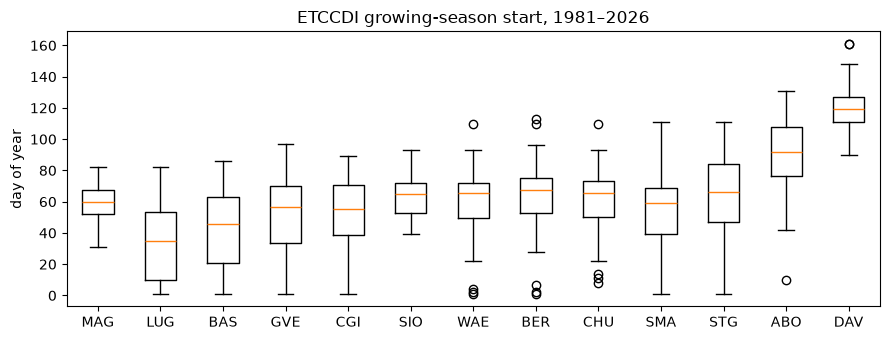

station,MAG,LUG,BAS,GVE,CGI,SIO,WAE,BER,CHU,SMA,STG,ABO,DAV
median start (day of year),59.5,35.0,46.0,56.5,55.5,65.0,65.5,67.5,65.5,59.0,66.5,92.0,119.0


In [6]:
def season_start(g):
    warm = (g.set_index("date")["tre200d0"] > 5).astype(int)
    run = warm.groupby((warm != warm.shift()).cumsum()).cumsum() * warm
    hit = run[run >= 6]
    return hit.index[0] - pd.Timedelta(days=5) if len(hit) else pd.NaT

h1 = daily[daily["month"] <= 6]
starts = h1.groupby(["station", "year"]).apply(season_start).rename("gs_start")
starts_doy = starts.dt.dayofyear.rename("gs_start_doy")

per = starts_doy[(starts_doy.index.get_level_values("year") >= COMPARISON_START) &
                 (starts_doy.index.get_level_values("year") <= last_complete)]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.boxplot([per.loc[s].dropna().values for s in order], tick_labels=list(order))
ax.set_ylabel("day of year"); ax.set_title(f"ETCCDI growing-season start, {COMPARISON_START}–{last_complete}")
plt.tight_layout(); plt.show()
per.groupby("station").median().loc[order].rename("median start (day of year)").to_frame().T

## 6. Observed flowering (phenology)
Each SMN station is matched to the nearest phenology station within 15 km and ±150 m elevation that has at least 20 years of **cherry full flowering** (`mprua65d`, 50 %) since 1981. Cherry is an early, widespread fruit-tree forage with WSU thresholds; dandelion (`mtaro65d`) and apple (`mmald65d`) are shown for context.

In [7]:
PHASES = {"mprua65d": "cherry 50 %", "mtaro65d": "dandelion 50 %", "mmald65d": "apple 50 %"}
pmeta = pd.read_csv(fetch(f"{PHEN}/ogd-phenology_meta_stations.csv", "ogd-phenology_meta_stations.csv"),
                    sep=";", encoding="latin1")

def load_phen(abbr):
    name = f"ogd-phenology_{abbr.lower()}_y.csv"
    df = pd.read_csv(fetch(f"{PHEN}/{abbr.lower()}/{name}", name), sep=";", encoding="latin1")
    df["year"] = pd.to_datetime(df["reference_timestamp"], format="%d.%m.%Y %H:%M").dt.year
    out = df[["year"]].copy()
    for p in PHASES:
        v = df[p] if p in df else pd.Series(np.nan, index=df.index)
        out[p] = pd.to_datetime(v.dropna().astype("int64").astype(str), format="%Y%m%d").dt.dayofyear
    return out.set_index("year")

matches, observed = [], []
for s in SAMPLE:
    m = sample_meta.loc[s]
    cand = pmeta.assign(km=np.hypot(pmeta["station_coordinates_lv95_east"] - m["east"],
                                    pmeta["station_coordinates_lv95_north"] - m["north"]) / 1000,
                        dz=pmeta["station_height_masl"] - m["elevation_m"])
    cand = cand[(cand["km"] <= 15) & (cand["dz"].abs() <= 150)].sort_values("km")
    for _, c in cand.iterrows():
        obs = load_phen(c["station_abbr"])
        n = obs.loc[COMPARISON_START:last_complete, "mprua65d"].notna().sum()
        if n >= 20:
            matches.append((s, c["station_abbr"], c["station_name"], round(c["km"], 1), int(c["dz"]), n))
            observed.append(obs.assign(station=s).reset_index())
            break
    else:
        matches.append((s, None, None, None, None, 0))

matches = pd.DataFrame(matches, columns=["station", "phen_station", "phen_name", "km", "dz_m", "cherry_years"]).set_index("station")
observed = pd.concat(observed).set_index(["station", "year"])
print(f"matched {matches['phen_station'].notna().sum()} of {len(SAMPLE)} stations")
display(matches.loc[order])
obs_cmp = observed[(observed.index.get_level_values("year") >= COMPARISON_START) & (observed.index.get_level_values("year") <= last_complete)]
print(f"Median flowering day of year, {COMPARISON_START}–{last_complete}:")
obs_cmp.groupby("station")[list(PHASES)].median().rename(columns=PHASES).reindex(order).dropna(how="all").round(0)

matched 11 of 13 stations


,phen_station,phen_name,km,dz_m,cherry_years
station,,,,,
MAG,VIR,"Vira, Gambarogno",7.3,7.0,41
LUG,NaN,NaN,NaN,NaN,0
BAS,BAB,Basel / Binningen,0.8,-1.0,38
GVE,VES,Versoix,4.8,29.0,38
CGI,CHI,Nyon / Changins,0.6,-23.0,42
SIO,LET,Leytron,9.3,-2.0,38
WAE,WAD,Wädenswil,0.3,-5.0,45
BER,WOR,Worb,11.4,47.0,41
CHU,CHR,Chur,0.9,84.0,41


Median flowering day of year, 1981–2026:


,cherry 50 %,dandelion 50 %,apple 50 %
station,,,
MAG,95.0,88.0,103.0
BAS,91.0,92.0,92.0
GVE,100.0,106.0,112.0
CGI,101.0,104.0,114.0
SIO,96.0,97.0,116.0
WAE,104.0,108.0,118.0
BER,107.0,103.0,116.0
CHU,97.0,106.0,112.0
SMA,100.0,106.0,117.0


### Does the ETCCDI start track flowering?
Lag = observed cherry flowering − ETCCDI start, per matched station-year.

In [8]:
cmpv = obs_cmp[["mprua65d"]].join(starts_doy).dropna()
cmpv["lag"] = cmpv["mprua65d"] - cmpv["gs_start_doy"]
by = cmpv.groupby("station").apply(lambda g: pd.Series({
    "n": len(g), "median lag (days)": g["lag"].median(), "IQR lag": g["lag"].quantile(.75) - g["lag"].quantile(.25),
    "r(start, flowering)": g["mprua65d"].corr(g["gs_start_doy"])}))
print(f"pooled: n={len(cmpv)}, median lag {cmpv['lag'].median():.0f} days, "
      f"r(start, flowering) = {cmpv['mprua65d'].corr(cmpv['gs_start_doy']):.2f}")
by.reindex(order).dropna().round(2)

pooled: n=458, median lag 40 days, r(start, flowering) = 0.47


,n,median lag (days),IQR lag,"r(start, flowering)"
station,,,,
MAG,41.0,36.0,14.00,0.60
BAS,38.0,45.0,37.75,0.30
GVE,38.0,41.0,28.25,0.52
CGI,42.0,44.5,25.25,0.30
SIO,38.0,32.0,17.50,0.70
WAE,45.0,40.0,22.00,0.47
BER,41.0,39.0,19.00,0.35
CHU,41.0,35.0,22.00,0.45
SMA,46.0,39.5,29.00,0.33


### Thermal-sum model for cherry flowering
Growing degree days (GDD) above 5 °C from 1 January (`tre200d0`). The threshold is the median GDD reached on observed flowering days. Validation: leave one station out — calibrate on the others, predict the left-out station. Compared with the ETCCDI start shifted by the median lag (also calibrated without the left-out station).

In [9]:
gdd = h1.join(valid_h1, on=["station", "year"])
gdd = gdd[gdd["ok_h1"] == True].sort_values(["station", "date"]).copy()
gdd["gdd"] = gdd["tre200d0"].sub(5).clip(lower=0).fillna(0).groupby([gdd["station"], gdd["year"]]).cumsum()

def predict_bloom(threshold, frame=gdd):
    hit = frame[frame["gdd"] >= threshold].groupby(["station", "year"])["doy"].min()
    allsy = frame.groupby(["station", "year"]).size().index
    return hit.reindex(allsy).fillna(999).rename("bloom_doy")

gdd_at_bloom = (gdd.merge(obs_cmp["mprua65d"].dropna().rename("obs").reset_index(), on=["station", "year"])
                   .query("doy == obs").set_index(["station", "year"])["gdd"])
THRESHOLD = gdd_at_bloom.median()
print(f"GDD>5 °C at observed cherry flowering: median {THRESHOLD:.0f} (IQR {gdd_at_bloom.quantile(.25):.0f}–{gdd_at_bloom.quantile(.75):.0f}), n={len(gdd_at_bloom)}")

rows = []
for s in gdd_at_bloom.index.get_level_values("station").unique():
    train = gdd_at_bloom.drop(index=s, level="station")
    pred_gdd = predict_bloom(train.median(), gdd[gdd["station"] == s])
    lag = cmpv.drop(index=s, level="station")["lag"].median()
    obs = obs_cmp.loc[s, "mprua65d"].dropna()
    df = pd.DataFrame({"obs": obs, "gdd": pred_gdd.loc[s].reindex(obs.index),
                       "etccdi": (starts_doy.loc[s] + lag).reindex(obs.index)}).dropna()
    rows.append((s, len(df), (df["gdd"] - df["obs"]).abs().mean(), (df["gdd"] - df["obs"]).mean(),
                 (df["etccdi"] - df["obs"]).abs().mean(), (df["etccdi"] - df["obs"]).mean()))
loso = pd.DataFrame(rows, columns=["station", "n", "MAE thermal sum", "bias thermal sum",
                                   "MAE ETCCDI+lag", "bias ETCCDI+lag"]).set_index("station")
w = loso["n"] / loso["n"].sum()
print(f"leave-one-station-out, weighted by years: MAE thermal sum {(loso['MAE thermal sum'] * w).sum():.1f} d, "
      f"MAE ETCCDI+lag {(loso['MAE ETCCDI+lag'] * w).sum():.1f} d")
loso.reindex(order).dropna().round(1)

GDD>5 °C at observed cherry flowering: median 136 (IQR 117–159), n=458


leave-one-station-out, weighted by years: MAE thermal sum 5.7 d, MAE ETCCDI+lag 16.7 d


,n,MAE thermal sum,bias thermal sum,MAE ETCCDI+lag,bias ETCCDI+lag
station,,,,,
MAG,41.0,5.4,-3.2,8.9,3.8
BAS,38.0,4.0,-2.1,20.6,-12.8
GVE,38.0,6.5,-1.1,17.3,-7.8
CGI,42.0,5.0,-2.6,18.0,-11.6
SIO,38.0,4.8,3.4,10.4,7.3
WAE,45.0,4.5,1.1,14.6,-4.1
BER,41.0,4.5,1.9,14.3,-5.9
CHU,41.0,4.5,1.4,13.6,-1.4
SMA,46.0,4.0,1.0,18.8,-7.1


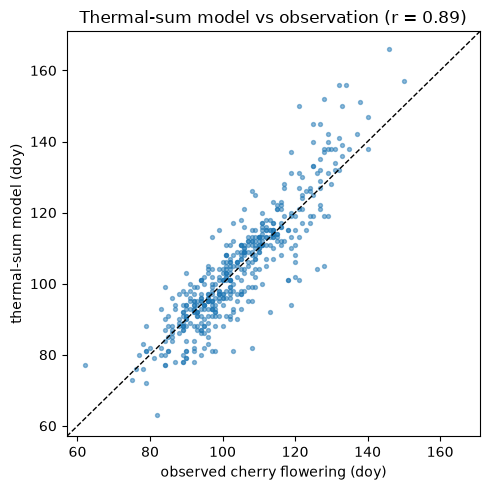

In [10]:
bloom_model = predict_bloom(THRESHOLD)
fig, ax = plt.subplots(figsize=(5, 5))
pair = obs_cmp[["mprua65d"]].join(bloom_model).dropna()
pair = pair[pair["bloom_doy"] < 999]
ax.scatter(pair["mprua65d"], pair["bloom_doy"], s=8, alpha=.5)
lim = [pair.min().min() - 5, pair.max().max() + 5]
ax.plot(lim, lim, "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("observed cherry flowering (doy)"); ax.set_ylabel("thermal-sum model (doy)")
ax.set_title(f"Thermal-sum model vs observation (r = {pair.corr().iloc[0, 1]:.2f})"); plt.tight_layout(); plt.show()

## 7. Candidate frost-day definitions
Mean events per valid station-year (March–June), comparison period.

| ID | Definition | Note |
|---|---|---|
| F1 | air ≤ 0 °C | prototype; no damage link |
| F2 | air ≤ −2.2 °C | bloom threshold, but applied to all of March–June |
| F3 | ground (5 cm) ≤ 0 °C | low-growing flora; no documented threshold |
| F4 | air ≤ 0 °C on/after ETCCDI start | timing proxy |
| F5 | air ≤ −2.2 °C on/after ETCCDI start | **mixes the bloom threshold with ETCCDI timing (often February), when buds are at early stages and hardy to about −8 to −9 °C** |
| F6 | air ≤ −2.2 °C on/after modelled cherry flowering | bloom threshold applied from (modelled) bloom; conservative because first bloom precedes 50 % flowering by a few days |

In [11]:
cmp = cmp.join(starts, on=["station", "year"]).join(bloom_model, on=["station", "year"])
cmp["after_gs"] = cmp["date"] >= cmp["gs_start"]
cmp["after_bloom"] = cmp["doy"] >= cmp["bloom_doy"]

DEFS = {
    "F1": ("tre200dn", None, lambda d: d["tre200dn"] <= 0),
    "F2": ("tre200dn", None, lambda d: d["tre200dn"] <= BLOSSOM_C),
    "F3": ("tre005dn", None, lambda d: d["tre005dn"] <= 0),
    "F4": ("tre200dn", "gs_start", lambda d: (d["tre200dn"] <= 0) & d["after_gs"]),
    "F5": ("tre200dn", "gs_start", lambda d: (d["tre200dn"] <= BLOSSOM_C) & d["after_gs"]),
    "F6": ("tre200dn", "bloom_doy", lambda d: (d["tre200dn"] <= BLOSSOM_C) & d["after_bloom"]),
}

def station_years(frame, defn):
    param, needs, rule = DEFS[defn]
    d = frame[frame[f"ok_{param}"] == True]
    if needs:
        d = d[d[needs].notna()]
    return d.assign(event=rule(d)).groupby(["station", "year"])["event"].sum()

sy = {k: station_years(cmp, k) for k in DEFS}
by_station = pd.DataFrame({k: v.groupby("station").mean() for k, v in sy.items()}).loc[order]
by_station.insert(0, "elevation_m", sample_meta.loc[order, "elevation_m"].astype(int))
by_station.round(2)

,elevation_m,F1,F2,F3,F4,F5,F6
station,,,,,,,
MAG,203,10.43,2.76,25.96,7.83,1.54,0.11
LUG,273,1.09,0.15,6.54,0.57,0.02,0.00
BAS,316,9.65,2.93,27.46,7.28,1.72,0.28
GVE,411,11.57,3.93,30.91,7.37,1.48,0.09
CGI,458,8.85,2.50,29.04,5.43,0.93,0.09
SIO,482,12.57,4.50,42.98,6.91,1.22,0.02
WAE,485,10.74,3.93,28.70,5.89,1.39,0.00
BER,553,17.93,7.20,47.46,10.91,3.07,0.26
CHU,556,11.37,4.11,25.70,6.65,1.61,0.13


### Share of springs with at least one event, per station
Checks whether a probability metric (M2) can discriminate between stations.

In [12]:
share = pd.DataFrame({k: (v > 0).groupby("station").mean() for k, v in sy.items()}).loc[order]
print("stations where fewer than 90 % of springs have an event:")
for k in DEFS:
    low_share = share.index[share[k] < 0.9].tolist()
    print(f"  {k}: {low_share if low_share else 'none'}")
share.round(2)

stations where fewer than 90 % of springs have an event:
  F1: ['LUG']
  F2: ['MAG', 'LUG', 'BAS', 'GVE', 'CGI', 'SIO', 'WAE', 'CHU', 'SMA']
  F3: ['LUG']
  F4: ['LUG']
  F5: ['MAG', 'LUG', 'BAS', 'GVE', 'CGI', 'SIO', 'WAE', 'BER', 'CHU', 'SMA', 'STG', 'ABO', 'DAV']
  F6: ['MAG', 'LUG', 'BAS', 'GVE', 'CGI', 'SIO', 'WAE', 'BER', 'CHU', 'SMA', 'STG', 'ABO', 'DAV']


,F1,F2,F3,F4,F5,F6
station,,,,,,
MAG,1.00,0.70,1.00,1.00,0.50,0.09
LUG,0.41,0.07,0.78,0.33,0.02,0.00
BAS,0.96,0.70,1.00,0.96,0.57,0.17
GVE,1.00,0.72,1.00,1.00,0.57,0.09
CGI,1.00,0.61,1.00,0.96,0.46,0.07
SIO,1.00,0.74,1.00,0.98,0.43,0.02
WAE,0.98,0.65,1.00,0.91,0.39,0.00
BER,1.00,0.96,1.00,0.98,0.72,0.11
CHU,0.98,0.78,1.00,0.91,0.57,0.11


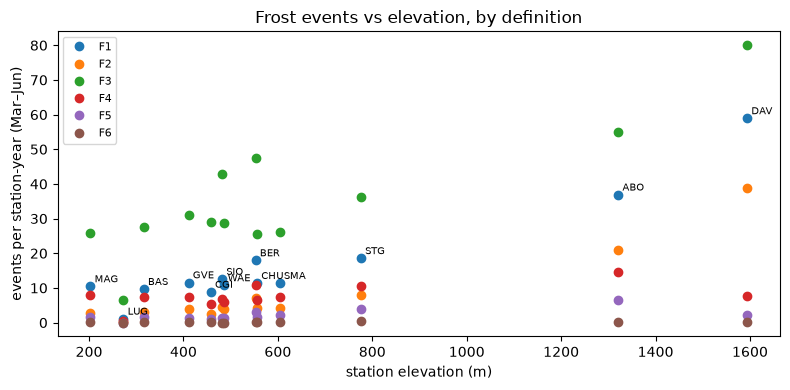

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
for k in DEFS:
    ax.plot(by_station["elevation_m"], by_station[k], "o", label=k)
for s, row in by_station.iterrows():
    ax.annotate(s, (row["elevation_m"], row["F1"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("station elevation (m)"); ax.set_ylabel("events per station-year (Mar–Jun)")
ax.set_title("Frost events vs elevation, by definition"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### Threshold sensitivity
All sample stations below 1000 m pooled.

In [14]:
low = [s for s in SAMPLE if sample_meta.at[s, "elevation_m"] < 1000]
thresholds = [0, -1, -2, -2.2, -3, -4]
rows = {}
for param, label in [("tre200dn", "air 2 m"), ("tre005dn", "ground 5 cm")]:
    d = cmp[(cmp[f"ok_{param}"] == True) & cmp["station"].isin(low)]
    rows[label] = {t: d.assign(e=d[param] <= t).groupby(["station", "year"])["e"].sum().mean() for t in thresholds}
sens = pd.DataFrame(rows).rename_axis("threshold °C")
sens["ground / air"] = sens["ground 5 cm"] / sens["air 2 m"]
sens.round(2)

,air 2 m,ground 5 cm,ground / air
threshold °C,,,
0.0,11.28,29.74,2.64
-1.0,7.10,22.73,3.20
-2.0,4.42,16.82,3.81
-2.2,4.00,15.80,3.95
-3.0,2.72,12.16,4.47
-4.0,1.61,8.57,5.31


## 8. Colonies per canton (2022)
Parsed from Agroscope Transfer 528, Table 2, and checked against the published Swiss total.

In [15]:
from pypdf import PdfReader

reader = PdfReader(fetch(AGROSCOPE_PDF, "agroscope-transfer-528-de.pdf"))
page = next(p.extract_text() for p in reader.pages if "Tabelle 2" in (p.extract_text() or ""))
num = r"\d{1,3}(?: \d{3})*"
records, total = [], None
for line in page.splitlines():
    m = re.match(rf"^\s*([A-Z]{{2}}|Schweiz)\s+({num})\s+({num})\s+({num})", line)
    if m:
        vals = [int(x.replace(" ", "")) for x in m.groups()[1:]]
        if m.group(1) == "Schweiz":
            total = vals[1]
        else:
            records.append((m.group(1), *vals))
hives = pd.DataFrame(records, columns=["canton", "beekeepers", "colonies", "area_km2"]).set_index("canton")
assert len(hives) == 26, len(hives)
assert hives["colonies"].sum() == total, (hives["colonies"].sum(), total)
print(f"26 cantons, {total:,} colonies (matches the published total)")
hives.sort_values("colonies", ascending=False).head(10)

26 cantons, 182,300 colonies (matches the published total)


,beekeepers,colonies,area_km2
canton,,,
BE,3230,32374,5959
ZH,1471,16662,1729
AG,1120,13583,1404
SG,1253,13156,2026
TI,512,12632,2812
LU,1058,12617,1493
VD,1069,12588,3212
VS,1086,10461,5224
FR,896,9134,1671


## 9. Canton metrics
- **M0 prototype:** events summed over a canton's stations ÷ colonies. **Rejected on mechanism:** the
  numerator grows with the number of stations and the denominator with colonies, so the value scales
  with stations ÷ colonies rather than with frost. With 9 cantons, rank correlations below cannot
  separate metrics statistically and are shown for description only.
- **M1 hazard:** mean events per valid station-year over the canton's stations. Stations are weighted
  **equally** within a canton — an arbitrary choice when stations differ strongly (e.g. Davos vs Chur).
- **M2 probability:** share of valid station-years with ≥ 1 event.
- **M3 exposure:** M1 × colonies (expected colony-frost-events per spring).

In [16]:
def canton_metrics(defn, stations_used=SAMPLE):
    s = sy[defn]
    s = s[s.index.get_level_values("station").isin(stations_used)]
    df = s.rename("events").reset_index().join(sample_meta["canton"], on="station")
    g = df.groupby("canton")
    out = pd.DataFrame({
        "stations": g["station"].unique().map(lambda a: ", ".join(sorted(a))),
        "n_stations": g["station"].nunique(),
        "station_years": g.size(),
        "M1_hazard": g["events"].mean(),
        "M2_probability": g["events"].apply(lambda e: (e > 0).mean()),
    }).join(hives["colonies"])
    out["M0_prototype"] = g["events"].sum() / out["colonies"]
    out["M3_exposure"] = out["M1_hazard"] * out["colonies"]
    return out

metrics = {k: canton_metrics(k) for k in DEFS}
single = metrics["F1"].index[metrics["F1"]["n_stations"] == 1].tolist()
print(f"{len(metrics['F1'])} cantons in the sample; {len(single)} rest on a single station: {single}")
top10 = hives["colonies"].nlargest(10)
missing = [c for c in top10.index if c not in metrics["F1"].index]
print(f"Of the 10 largest colony cantons, not in the sample (no M3 value): {missing} "
      f"({hives.loc[missing, 'colonies'].sum():,} colonies, {hives.loc[missing, 'colonies'].sum() / total:.0%} of Switzerland)")
f6 = metrics["F6"].drop(columns="stations").copy()
k_n = sy["F6"].gt(0).rename("hit").reset_index().join(sample_meta["canton"], on="station").groupby("canton")["hit"].agg(["sum", "count"])
f6["M2 95% CI"] = [f"{lo:.2f}–{hi:.2f}" for lo, hi in (wilson(k, n) for k, n in zip(k_n.loc[f6.index, "sum"], k_n.loc[f6.index, "count"]))]
print("\nCanton values, F6 (M2 with Wilson 95 % interval):")
print(f6.round(3).sort_values("M1_hazard", ascending=False).to_string())

9 cantons in the sample; 5 rest on a single station: ['BL', 'GE', 'SG', 'VD', 'VS']
Of the 10 largest colony cantons, not in the sample (no M3 value): ['AG', 'LU', 'FR'] (35,334 colonies, 19% of Switzerland)

Canton values, F6 (M2 with Wilson 95 % interval):
        n_stations  station_years  M1_hazard  M2_probability  colonies  M0_prototype  M3_exposure  M2 95% CI
canton                                                                                                      
SG               1             46      0.370           0.109     13156         0.001     4862.000  0.05–0.23
BL               1             46      0.283           0.174      2147         0.006      606.761  0.09–0.31
BE               2             92      0.239           0.076     32374         0.001     7741.609  0.04–0.15
GR               2             92      0.130           0.098      8468         0.001     1104.522  0.05–0.18
GE               1             46      0.087           0.087      3301         0.001   

In [17]:
cols = ["M0_prototype", "M1_hazard", "M2_probability", "M3_exposure"]
ranks = pd.DataFrame({f"{k} {m}": metrics[k][m].rank(ascending=False, method="min").astype(int)
                      for k in ["F1", "F2", "F6"] for m in cols})
print("Rank per canton (1 = highest risk):")
print(ranks.sort_values("F6 M1_hazard").to_string())
print(f"\nSpearman rank correlation between metrics (descriptive, n = {len(ranks)} cantons):")
for k in ["F1", "F2", "F5", "F6"]:
    print(f"\n{k}\n" + metrics[k][cols].corr(method="spearman").round(2).to_string())

Rank per canton (1 = highest risk):
        F1 M0_prototype  F1 M1_hazard  F1 M2_probability  F1 M3_exposure  F2 M0_prototype  F2 M1_hazard  F2 M2_probability  F2 M3_exposure  F6 M0_prototype  F6 M1_hazard  F6 M2_probability  F6 M3_exposure
canton                                                                                                                                                                                                      
SG                    5             3                  1               3                5             3                  2               3                3             1                  2               2
BL                    2             7                  8               9                2             7                  6               9                1             2                  1               6
BE                    4             2                  1               1                4             2                  1               1      

### Elevation cap (assumption)
Recomputing M1 from stations below 1000 m only. **Assumption:** most colonies are kept below 1000 m
(apiary elevations are not public; not verified). **Trade-off:** the cap removes the highest-hazard
areas (here Davos and Adelboden) and the colonies kept there; without it, a single high station can
dominate a canton (GR, BE).

In [18]:
elev = pd.DataFrame({
    "stations (all)": metrics["F6"]["stations"],
    "M1 F6 all": metrics["F6"]["M1_hazard"],
    "M1 F6 < 1000 m": canton_metrics("F6", low)["M1_hazard"],
    "M1 F2 all": metrics["F2"]["M1_hazard"],
    "M1 F2 < 1000 m": canton_metrics("F2", low)["M1_hazard"],
})
print(elev.round(2).to_string())

       stations (all)  M1 F6 all  M1 F6 < 1000 m  M1 F2 all  M1 F2 < 1000 m
canton                                                                     
BE           ABO, BER       0.24            0.26      14.04            7.20
BL                BAS       0.28            0.28       2.93            2.93
GE                GVE       0.09            0.09       3.93            3.93
GR           CHU, DAV       0.13            0.13      21.45            4.11
SG                STG       0.37            0.37       7.89            7.89
TI           LUG, MAG       0.05            0.05       1.46            1.46
VD                CGI       0.09            0.09       2.50            2.50
VS                SIO       0.02            0.02       4.50            4.50
ZH           SMA, WAE       0.03            0.03       4.03            4.03


## 10. Long-term change
Stations with records since at least 1901. Raw, non-homogenised series: station moves and instrument changes can shift values, so results are indicative only. Annual values are the mean over the stations valid that year. The modelled flowering date for years before 1981 assumes the thermal-sum threshold calibrated on 1981–present holds.

long-record stations: ['BAS', 'BER', 'LUG', 'DAV', 'SMA', 'STG']


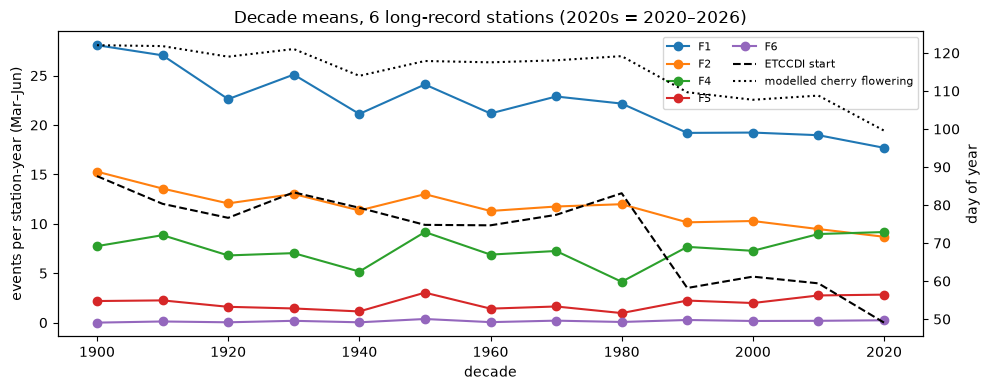

,F1,F2,F4,F5,F6,gs_start_doy,bloom_model_doy
decade,,,,,,,
1900,28.07,15.28,7.74,2.19,0.00,87.61,122.04
1910,27.05,13.57,8.85,2.25,0.12,80.32,121.80
1920,22.62,12.07,6.80,1.60,0.03,76.63,119.02
1930,25.10,13.02,7.03,1.43,0.18,83.33,121.03
1940,21.12,11.35,5.17,1.13,0.03,79.28,113.98
1950,24.10,13.00,9.17,3.03,0.37,74.78,117.88
1960,21.17,11.30,6.88,1.42,0.05,74.67,117.53
1970,22.88,11.75,7.25,1.63,0.20,77.42,118.06
1980,22.17,11.98,4.13,0.97,0.07,83.10,119.16


In [19]:
first_year = daily.dropna(subset=["tre200dn"]).groupby("station")["year"].min()
long_rec = [s for s in SAMPLE if first_year[s] <= 1901]
print("long-record stations:", long_rec)

hist = spring[spring["station"].isin(long_rec) & (spring["year"] >= 1901) & (spring["year"] <= last_complete)].copy()
hist = (hist.join(valid.rename(columns=lambda c: f"ok_{c}"), on=["station", "year"])
            .join(starts, on=["station", "year"]).join(bloom_model, on=["station", "year"]))
hist["after_gs"] = hist["date"] >= hist["gs_start"]
hist["after_bloom"] = hist["doy"] >= hist["bloom_doy"]

TREND_DEFS = ["F1", "F2", "F4", "F5", "F6"]
sy_hist = pd.DataFrame({k: station_years(hist, k) for k in TREND_DEFS})
sy_hist = sy_hist.join(starts_doy).join(bloom_model.where(bloom_model < 999).rename("bloom_model_doy"))
annual = sy_hist.groupby("year").mean()

dec = annual.groupby(annual.index // 10 * 10).mean()
dec.index.name = "decade"
fig, ax1 = plt.subplots(figsize=(10, 4))
for c in TREND_DEFS:
    ax1.plot(dec.index, dec[c], marker="o", label=c)
ax1.set_ylabel("events per station-year (Mar–Jun)"); ax1.set_xlabel("decade")
ax2 = ax1.twinx()
ax2.plot(dec.index, dec["gs_start_doy"], "k--", label="ETCCDI start")
ax2.plot(dec.index, dec["bloom_model_doy"], "k:", label="modelled cherry flowering")
ax2.set_ylabel("day of year")
h1_, l1 = ax1.get_legend_handles_labels(); h2_, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1_ + h2_, l1 + l2, fontsize=8, loc="upper right", ncol=2)
ax1.set_title(f"Decade means, {len(long_rec)} long-record stations (2020s = 2020–{last_complete})"); plt.tight_layout(); plt.show()
dec.round(2)

### Trend estimates
Sen's slope (Theil–Sen) per decade with 95 % confidence interval, and Kendall's τ p-value, on the annual station-mean series. Serial correlation is not accounted for, so p-values are optimistic. For F6, most annual values are zero, so Sen's slope is 0 by construction and uninformative; F6 is tested as a rare event below.

In [20]:
def sen(series, start, end=last_complete):
    s = series.loc[start:end].dropna()
    slope, _, lo, hi = theilslopes(s.values, s.index.values, alpha=0.95)
    tau, p = kendalltau(s.index.values, s.values)
    return pd.Series({"years": len(s), "slope/decade": slope * 10, "CI low": lo * 10, "CI high": hi * 10, "Kendall p": p})

series_cols = TREND_DEFS + ["gs_start_doy", "bloom_model_doy"]
trend_tab = pd.concat({f"{a}–{last_complete}": pd.DataFrame({c: sen(annual[c], a) for c in series_cols}).T
                       for a in (1901, 1961, 1981)})
print(trend_tab.round(3).to_string())

                           years  slope/decade  CI low  CI high  Kendall p
1901–2026 F1               126.0        -0.708  -0.962   -0.458      0.000
          F2               126.0        -0.398  -0.578   -0.211      0.000
          F4               126.0         0.042  -0.128    0.212      0.649
          F5               126.0         0.027  -0.035    0.096      0.379
          F6               126.0        -0.000  -0.000   -0.000      0.049
          gs_start_doy     126.0        -2.372  -3.131   -1.633      0.000
          bloom_model_doy  126.0        -1.398  -1.778   -0.984      0.000
1961–2026 F1                66.0        -0.758  -1.410   -0.128      0.020
          F2                66.0        -0.513  -0.952   -0.000      0.044
          F4                66.0         0.433  -0.000    0.881      0.070
          F5                66.0         0.196  -0.000    0.417      0.039
          F6                66.0        -0.000  -0.000   -0.000      0.467
          gs_start_doy   

### Last frost versus vegetation timing
Per valid station-year: the last day (1 January – 30 June) with air minimum ≤ 0 °C and ≤ −2.2 °C, and its gap to the ETCCDI start and to modelled cherry flowering. A positive gap means the last frost came after green-up/flowering. If the gap to flowering **widens**, exposure of open blossom to frost is increasing independently of how the counting window is defined. Station-years without a frost at the threshold are excluded (count shown).

station-years: 756; without frost ≤ 0 °C: 0, without frost ≤ −2.2 °C: 18
                            years  slope/decade  CI low  CI high  Kendall p
1901–2026 last_frost_0      126.0        -1.640  -2.123   -1.135      0.000
          last_frost_2.2    126.0        -0.882  -1.413   -0.321      0.002
          gap_0_to_start    126.0         0.903   0.158    1.667      0.018
          gap_2.2_to_bloom  126.0         0.143  -0.412    0.705      0.614
1961–2026 last_frost_0       66.0        -2.297  -3.651   -0.889      0.001
          last_frost_2.2     66.0        -1.212  -2.704    0.243      0.139
          gap_0_to_start     66.0         2.667   0.606    4.684      0.011
          gap_2.2_to_bloom   66.0         1.179  -0.480    3.069      0.149
1981–2026 last_frost_0       46.0        -2.292  -4.394   -0.000      0.047
          last_frost_2.2     46.0        -0.750  -3.458    2.242      0.520
          gap_0_to_start     46.0         4.286   0.682    8.095      0.021
          gap_2

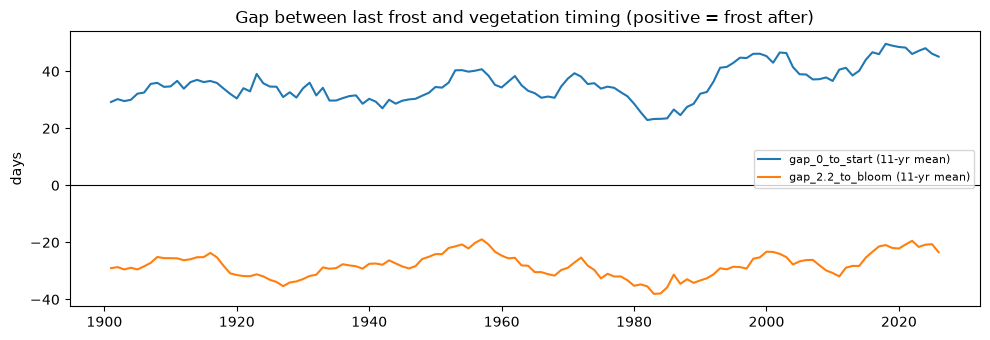

In [21]:
jan_jun = daily[daily["station"].isin(long_rec) & (daily["month"] <= 6) & (daily["year"] >= 1901) & (daily["year"] <= last_complete)]
jan_jun = jan_jun.join(valid["tre200dn"].rename("ok"), on=["station", "year"])
jan_jun = jan_jun[jan_jun["ok"] == True]
lf = pd.DataFrame({
    "last_frost_0": jan_jun[jan_jun["tre200dn"] <= 0].groupby(["station", "year"])["doy"].max(),
    "last_frost_2.2": jan_jun[jan_jun["tre200dn"] <= BLOSSOM_C].groupby(["station", "year"])["doy"].max(),
}).join(starts_doy).join(bloom_model.where(bloom_model < 999).rename("bloom_model_doy"))
lf["gap_0_to_start"] = lf["last_frost_0"] - lf["gs_start_doy"]
lf["gap_2.2_to_bloom"] = lf["last_frost_2.2"] - lf["bloom_model_doy"]
all_sy = jan_jun.groupby(["station", "year"]).size()
print(f"station-years: {len(all_sy)}; without frost ≤ 0 °C: {len(all_sy) - lf['last_frost_0'].notna().sum()}, "
      f"without frost ≤ −2.2 °C: {len(all_sy) - lf['last_frost_2.2'].notna().sum()}")

annual_lf = lf.groupby("year").mean()
lf_cols = ["last_frost_0", "last_frost_2.2", "gap_0_to_start", "gap_2.2_to_bloom"]
lf_tab = pd.concat({f"{a}–{last_complete}": pd.DataFrame({c: sen(annual_lf[c], a) for c in lf_cols}).T for a in (1901, 1961, 1981)})
print(lf_tab.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 3.5))
for c in ["gap_0_to_start", "gap_2.2_to_bloom"]:
    ax.plot(annual_lf.index, annual_lf[c].rolling(11, center=True, min_periods=6).mean(), label=f"{c} (11-yr mean)")
ax.axhline(0, color="k", lw=.8); ax.set_ylabel("days"); ax.legend(fontsize=8)
ax.set_title("Gap between last frost and vegetation timing (positive = frost after)"); plt.tight_layout(); plt.show()

### Check with observed flowering
Same gap with **observed** cherry flowering, for all matched stations (not only long-record ones), 1981–present: last frost ≤ −2.2 °C minus observed flowering day.

In [22]:
jj = daily[(daily["month"] <= 6) & (daily["year"] >= COMPARISON_START) & (daily["year"] <= last_complete)]
jj = jj.join(valid["tre200dn"].rename("ok"), on=["station", "year"])
jj = jj[jj["ok"] == True]
obs_gap = (jj[jj["tre200dn"] <= BLOSSOM_C].groupby(["station", "year"])["doy"].max().rename("last_frost_2.2")
           .to_frame().join(obs_cmp["mprua65d"]).dropna())
obs_gap["gap"] = obs_gap["last_frost_2.2"] - obs_gap["mprua65d"]
obs_gap["frost_after_flowering"] = obs_gap["gap"] >= 0
ann = obs_gap.groupby("year").agg(gap=("gap", "mean"), share_after=("frost_after_flowering", "mean"),
                                  flowering=("mprua65d", "mean"))
print(f"{obs_gap.index.get_level_values('station').nunique()} stations, {len(obs_gap)} station-years with a frost ≤ −2.2 °C and an observation")
print(pd.DataFrame({c: sen(ann[c], COMPARISON_START) for c in ["flowering", "gap"]}).T.round(3).to_string())

11 stations, 458 station-years with a frost ≤ −2.2 °C and an observation
           years  slope/decade  CI low  CI high  Kendall p
flowering   46.0        -3.289  -4.722   -1.405      0.003
gap         46.0        -0.244  -2.624    2.900      0.932


### F6 as a rare event
Share of station-years with at least one F6 event (modelled flowering, long-record stations) and with at least one frost ≤ −2.2 °C on or after **observed** cherry flowering (matched stations), by period, with Wilson 95 % intervals and Fisher's exact test between the first and last period.

In [23]:
def period_table(hits, periods):
    rows = []
    for a, b in periods:
        h = hits[(hits.index.get_level_values("year") >= a) & (hits.index.get_level_values("year") <= b)]
        lo, hi = wilson(int(h.sum()), len(h))
        rows.append((f"{a}–{b}", len(h), int(h.sum()), h.mean(), lo, hi))
    tab = pd.DataFrame(rows, columns=["period", "station-years", "with event", "share", "CI low", "CI high"]).set_index("period")
    first, last = tab.iloc[0], tab.iloc[-1]
    odds, p = fisher_exact([[first["with event"], first["station-years"] - first["with event"]],
                            [last["with event"], last["station-years"] - last["with event"]]])
    return tab, odds, p

modelled = sy_hist["F6"].dropna() > 0
tab, odds, p = period_table(modelled, [(1901, 1960), (1961, 1990), (1991, last_complete)])
print(f"Modelled flowering, long-record stations {long_rec}:")
print(tab.round(3).to_string()); print(f"Fisher exact, first vs last period: odds ratio {odds:.2f}, p = {p:.3f}")

after_obs = jj.join(obs_cmp["mprua65d"], on=["station", "year"]).dropna(subset=["mprua65d"])
obs_hits = (after_obs.assign(e=(after_obs["tre200dn"] <= BLOSSOM_C) & (after_obs["doy"] >= after_obs["mprua65d"]))
                     .groupby(["station", "year"])["e"].any())
mid = (COMPARISON_START + last_complete) // 2
tab, odds, p = period_table(obs_hits, [(COMPARISON_START, mid), (mid + 1, last_complete)])
print(f"\nObserved cherry flowering, {obs_hits.index.get_level_values('station').nunique()} matched stations:")
print(tab.round(3).to_string()); print(f"Fisher exact: odds ratio {odds:.2f}, p = {p:.3f}")

Modelled flowering, long-record stations ['BAS', 'BER', 'LUG', 'DAV', 'SMA', 'STG']:
           station-years  with event  share  CI low  CI high
period                                                      
1901–1960            360          23  0.064   0.043    0.094
1961–1990            180          12  0.067   0.039    0.113
1991–2026            216          22  0.102   0.068    0.149
Fisher exact, first vs last period: odds ratio 0.60, p = 0.110

Observed cherry flowering, 11 matched stations:
           station-years  with event  share  CI low  CI high
period                                                      
1981–2003            239          21  0.088   0.058    0.131
2004–2026            219          18  0.082   0.053    0.126
Fisher exact: odds ratio 1.08, p = 0.868


## 11. Findings for ADR-002

Values from the committed run: comparison period 1981–2026, 13 stations in 9 cantons; trends on 6 long-record stations (raw, non-homogenised series). Target mechanism: **forage loss** (frost on open blossom); brood chilling is not analysed.

1. **Calendar window.** At stations below 800 m most air frost days fall in **March** (7–14 per spring; Lugano 1) and few in April (0–5.5); May and June are almost frost-free. Observed cherry flowering is in April (median day 91–118 below 800 m). A calendar window therefore mostly counts frost before bloom.
2. **Bud stage matters.** WSU EB0913/EB1128 give 10 % kill at −2.2 °C only from about first bloom; earlier stages tolerate −2.8 to −9.4 °C (apple) and −3.3 to −8.3 °C (cherry). F2 (−2.2 °C in March–June) and F5 (−2.2 °C from the ETCCDI start, often February) apply the bloom threshold to hardy buds and overcount.
3. **The ETCCDI start is not a vegetation signal.** Against observed cherry flowering (11 matched stations, 458 station-years) it correlates weakly (r = 0.47) and precedes flowering by a median 40 days; shifted by that lag it predicts flowering with a leave-one-station-out error of 16.7 days. A thermal sum (GDD > 5 °C from 1 January reaching 136, IQR 117–159) predicts it with 5.7 days (worst: Adelboden 10.9 days, 10.8 days too late).
4. **Frost on open blossom (F6) is rare.** −2.2 °C on or after modelled cherry flowering occurs 0–0.37 times per spring (0–17 % of springs) at the sample stations. Because flowering is later at altitude, F6 depends far less on elevation than F1/F2 (Adelboden 0.22, Davos 0.13). At altitude the model is biased late (Adelboden) or extrapolated (Davos has no matched phenology station), so F6 may be underestimated there.
5. **Elevation and siting dominate the threshold-only definitions.** Davos (1594 m) has ~59 and Adelboden (1321 m) ~37 air frost days per spring, against 1–19 below 800 m; Lugano 1.1 vs Magadino 10.4 at similar elevation (valley-floor cold-air pooling). With F2, GR's hazard is 21.5 with Davos and 4.1 with Chur only; BE 14.0 vs 7.2. With F6 the cap changes little (BE 0.24 vs 0.26).
6. **Canton aggregation is thin.** 5 of the 9 sample cantons rest on one station (BL, GE, SG, VD, VS); where there are two, they are weighted equally, which is arbitrary (Davos and Chur). AG, LU and FR — three of the ten largest colony cantons, 35,334 colonies (19 %) — have no station in the sample, so M3 covers only 9 cantons. For F6 the canton probabilities' 95 % intervals overlap widely (e.g. SG 0.05–0.23, VS 0.00–0.11): the sample cannot rank cantons reliably.
7. **Metrics.** M0 (events summed over stations ÷ colonies) is rejected on mechanism: it scales with stations ÷ colonies, not with frost. With n = 9 cantons the Spearman values (printed in §9) are descriptive only. M2 saturates for F1, F3 and F4 (every station except Lugano has an event in ≥ 90 % of springs; Lugano 0.41, 0.78, 0.33) and only discriminates for F2, F5 and F6; for the rare F6, M1 and M2 are nearly the same.
8. **Thresholds.** Below 1000 m: 11.3 air frost days (≤ 0 °C) vs 4.0 at ≤ −2.2 °C per spring; the ground minimum gives 2.6–5.3× more events than air, depending on the threshold.
9. **Change over time.** Frost days fell: F1 −0.71 per decade since 1901 (95 % CI −0.96 to −0.46), F2 −0.40 (−0.58 to −0.21). **Frost after the ETCCDI start shows no downward trend, unlike F1/F2**: F4 +0.04 (−0.13 to 0.21) and F5 +0.03 (−0.04 to 0.10) since 1901. Their rise since 1981 (F4 +1.11, CI 0.30 to 1.81) starts from the 1980s low point (F4 4.13; the 1950s and 2020s are both 9.17) and is partly **definitional**: the ETCCDI start moved earlier by 6.3 days per decade since 1981 (−10.4 to −2.4), faster than the last frost ≤ 0 °C (−2.3, −4.4 to 0.0), so the gap between them widened by 4.3 days per decade (0.7 to 8.1) and the window opens further into March. Against **flowering** there is no detectable change: modelled flowering advanced 1.4 days per decade since 1901 (observed: 3.3 since 1981), roughly in step with the last frost ≤ −2.2 °C (−0.9 since 1901); the gap between them changed by +0.14 days per decade since 1901 (−0.41 to 0.71), +2.5 since 1981 (−0.67 to 5.42), and −0.24 since 1981 with observed flowering (−2.6 to 2.9). The share of springs with frost on open blossom was 6.4 % (1901–1960), 6.7 % (1961–1990) and 10.2 % (1991–2026), Fisher p = 0.11; with observed flowering 8.8 % (1981–2003) vs 8.2 % (2004–2026), p = 0.87. This sample neither confirms nor rules out the increase in frost risk to vegetation reported by Vitasse & Rebetez (2018) for other species and sites.

**Limitations.** Station data are not homogenised; trend tests ignore serial correlation; the thermal-sum threshold is calibrated on 1981–2026 and assumed stable before; cherry 50 % flowering is later than first bloom, so F6 is conservative; one forage species; colony counts are one year (2022) and per canton only, without apiary locations or elevations; 13 stations in 9 cantons.

**Options for ADR-002** (the owner decides):
- *Mechanism:* forage loss (analysed here) and/or brood chilling (needs a cold-spell definition and its own exploration).
- *Frost definition:* F6 (≤ −2.2 °C on or after thermal-sum cherry flowering), optionally with stage-dependent thresholds before bloom (e.g. −3.3 °C at tight cluster); or F2 as a simpler calendar alternative that overcounts pre-bloom frost. F5 mixes a bloom threshold with ETCCDI timing and is not stage-consistent.
- *Metric:* hazard (M1, or M2 "in x of 100 springs" for rare events) with an uncertainty interval, and exposure (M3) reported separately; M0 dropped.
- *Aggregation:* equal or other station weighting within cantons, and whether to cap elevation (assumption: most apiaries below 1000 m, unverified; trade-off: removes high-hazard areas). Before publishing a canton ranking, more stations per canton and the missing large colony cantons (AG, LU, FR) are needed.